In [10]:
# Configurações Iniciais
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from google.colab import drive # importa a função drive do módulo google.colab
drive.mount('/content/drive') #conectar seu Google Drive ao ambiente do Colab

import os  #importa o módulo os
os.chdir("/content/drive/") # muda o diretório de trabalho atual para /content/drive/
!ls # exibirá todos os arquivos e pastas que estão diretamente dentro do seu Google Drive montado.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MyDrive  Othercomputers


In [11]:
# 1. Carregar o arquivo CSV
# Substitua pelo caminho correto do seu arquivo local, se necessário
df = pd.read_csv('/content/drive/MyDrive/Seminario/B2W-Reviews01_no_neutral_train.csv')
df2 = pd.read_csv('/content/drive/MyDrive/Seminario/B2W-Reviews01_inferred_bertimbau.csv')



/tmp/ipykernel_1838/17975794.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('/content/drive/MyDrive/Seminario/B2W-Reviews01_inferred_bertimbau.csv')


Figura 2 - Top 20 palavras Mais Frequentes

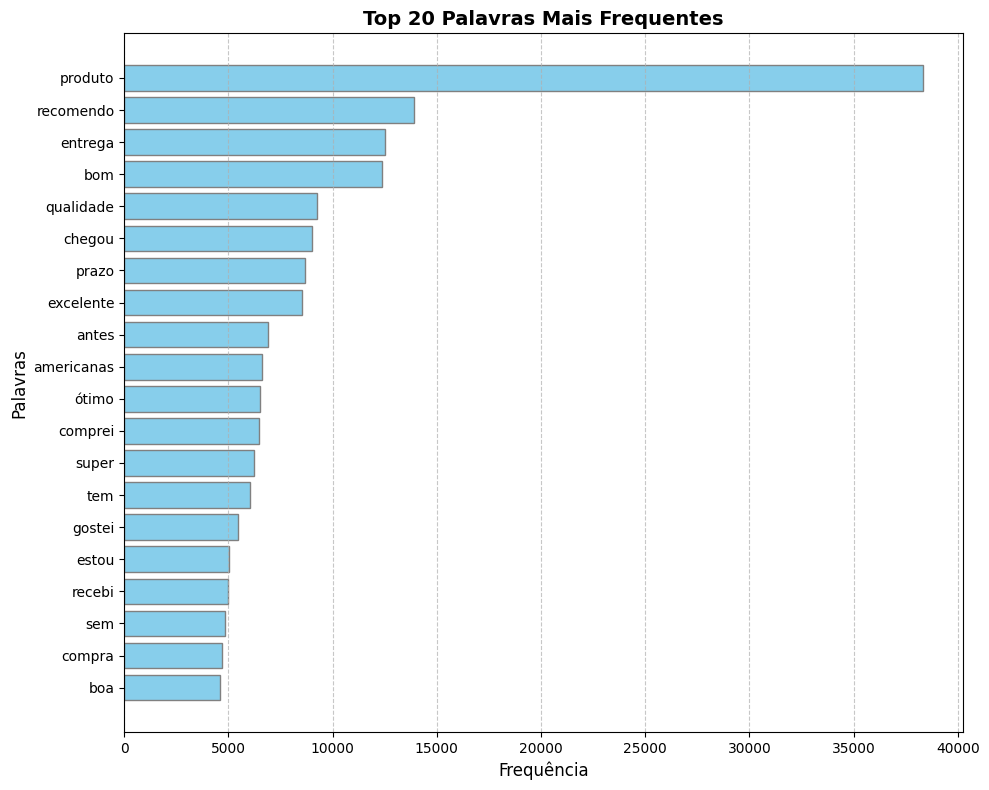

In [ ]:
# 2. Definir uma lista básica de stopwords em português para limpar o gráfico
stopwords_pt = {
    'o', 'a', 'os', 'as', 'um', 'uma', 'uns', 'umas', 'de', 'do', 'da', 'dos', 'das',
    'em', 'no', 'na', 'nos', 'nas', 'por', 'para', 'com', 'como', 'que', 'se', 'e', 'é',
    'ao', 'aos', 'me', 'mim', 'comigo', 'te', 'ti', 'contigo', 'ele', 'ela', 'eles', 'elas',
    'não', 'sim', 'mais', 'menos', 'muito', 'pouco', 'já', 'tudo', 'nada', 'este', 'esta',
    'estes', 'estas', 'isto', 'esse', 'essa', 'esses', 'essas', 'isso', 'aquele', 'aquela',
    'aqueles', 'aquelas', 'aquilo', 'meu', 'minha', 'meus', 'minhas', 'seu', 'sua', 'seus', 'suas',
    'foi', 'foram', 'ser', 'ter', 'uma', 'bem', 'mas', 'também', 'está'
}

# 3. Concatenar e processar os textos das avaliações
textos = df['review_text'].dropna().astype(str).str.lower()

todas_palavras = []
for texto in textos:
    # Captura apenas palavras compostas por letras (remove pontuações e números)
    palavras = re.findall(r'\b[a-záâãéêíóôõúç]+\b', texto)
    # Filtra palavras pequenas (com menos de 3 letras) e stopwords
    palavras_filtradas = [w for w in palavras if len(w) > 2 and w not in stopwords_pt]
    todas_palavras.extend(palavras_filtradas)

# 4. Contar a frequência e selecionar as top 20
contador = Counter(todas_palavras)
top_20 = contador.most_common(20)

# Converter em DataFrame e ordenar de forma ascendente para o gráfico horizontal
df_top20 = pd.DataFrame(top_20, columns=['Palavra', 'Frequência']).sort_values(by='Frequência', ascending=True)

# 5. Plotar o gráfico de barras horizontal (histograma de palavras)
plt.figure(figsize=(10, 8))
plt.barh(df_top20['Palavra'], df_top20['Frequência'], color='skyblue', edgecolor='gray')
plt.title('Top 20 Palavras Mais Frequentes', fontsize=14, fontweight='bold')
plt.xlabel('Frequência', fontsize=12)
plt.ylabel('Palavras', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Exibir ou salvar o gráfico
plt.show()

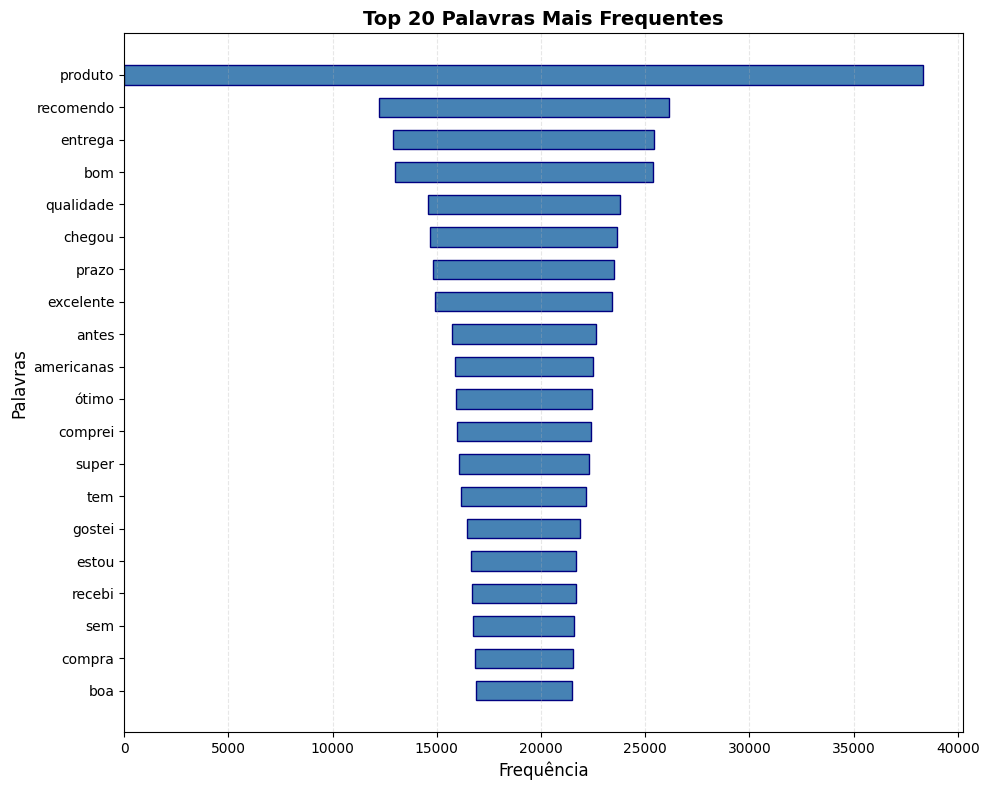

In [ ]:
# Gerando a vizualização de funil para exibir o resultado de 20 palavras

# 2. Lista de stopwords em português para limpeza do texto
stopwords_pt = {
    'o', 'a', 'os', 'as', 'um', 'uma', 'uns', 'umas', 'de', 'do', 'da', 'dos', 'das',
    'em', 'no', 'na', 'nos', 'nas', 'por', 'para', 'com', 'como', 'que', 'se', 'e', 'é',
    'ao', 'aos', 'me', 'mim', 'comigo', 'te', 'ti', 'contigo', 'ele', 'ela', 'eles', 'elas',
    'não', 'sim', 'mais', 'menos', 'muito', 'pouco', 'já', 'tudo', 'nada', 'este', 'esta',
    'estes', 'estas', 'isto', 'esse', 'essa', 'esses', 'essas', 'isso', 'aquele', 'aquela',
    'aqueles', 'aquelas', 'aquilo', 'meu', 'minha', 'meus', 'minhas', 'seu', 'sua', 'seus', 'suas',
    'foi', 'foram', 'ser', 'ter', 'uma', 'bem', 'mas', 'também', 'está', 'vou', 'veio', 'pra'
}

# 3. Processar os textos das avaliações
textos = df['review_text'].dropna().astype(str).str.lower()

todas_palavras = []
for texto in textos:
    palavras = re.findall(r'\b[a-záâãéêíóôõúç]+\b', texto)
    palavras_filtradas = [w for w in palavras if len(w) > 2 and w not in stopwords_pt]
    todas_palavras.extend(palavras_filtradas)

# 4. Contar a frequência e extrair as Top 20
contador = Counter(todas_palavras)
top_20 = contador.most_common(20)

# Criar DataFrame ordenado explicitamente do MAIOR para o MENOR
df_funil = pd.DataFrame(top_20, columns=['Palavra', 'Frequência']).sort_values(by='Frequência', ascending=False)

# 5. Construir o gráfico de Funil Azul (Maior para Menor)
plt.figure(figsize=(10, 8))

max_freq = df_funil['Frequência'].max()
# Calcula os recuos à esquerda para manter a centralização de cada barra
left_positions = (max_freq - df_funil['Frequência']) / 2

# Plotando as barras com os novos tons de azul
plt.barh(df_funil['Palavra'],
         df_funil['Frequência'],
         left=left_positions,
         color='steelblue',       # <--- Cor interna das barras alterada para azul
         edgecolor='navy',         # <--- Cor da borda das barras alterada para azul escuro
         height=0.6)

# Títulos e labels
plt.title('Top 20 Palavras Mais Frequentes', fontsize=14, fontweight='bold')
plt.xlabel('Frequência', fontsize=12)
plt.ylabel('Palavras', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Inverte o eixo Y para forçar a maior palavra a subir para o topo
plt.gca().invert_yaxis()

plt.tight_layout()

# Exibir gráfico
plt.show()

Figura 3 - Top 10 categorias com mais produtos únicos

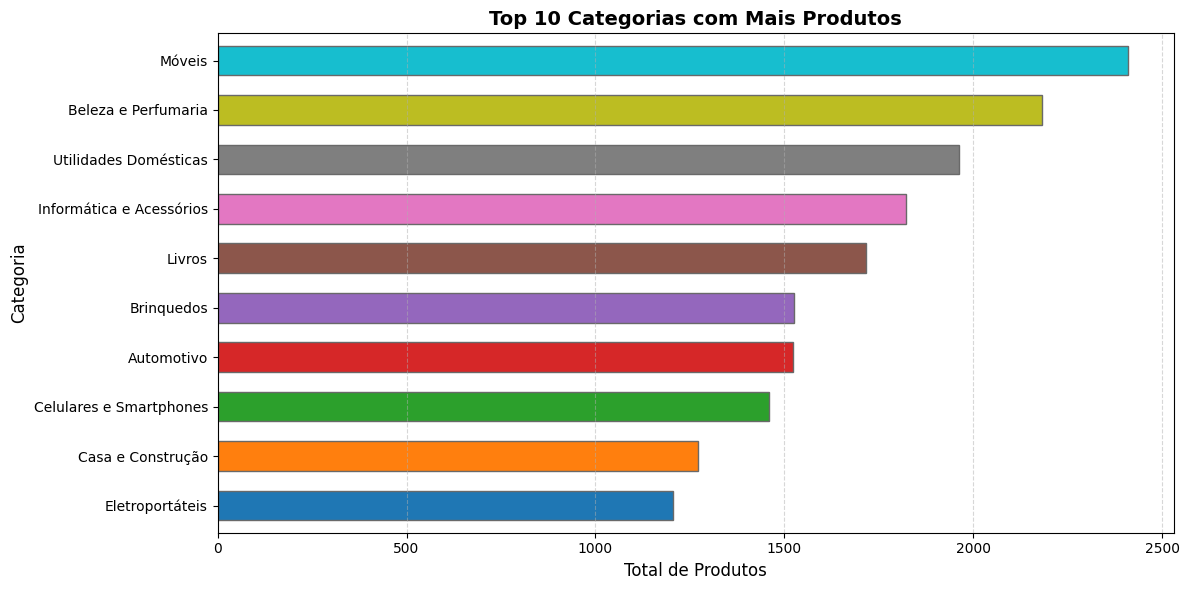

In [ ]:
# 2. Agrupar por categoria e contar a quantidade de produtos únicos
top_10_categorias = (
    df.groupby('site_category_lv1')['product_id']
    .nunique()
    .sort_values(ascending=True) # Mantém a maior barra no topo
    .tail(10)
)

# 3. Criar a visualização
plt.figure(figsize=(12, 6))

# O truque está aqui: passamos uma lista de cores gerada pelo colormap 'tab10'
cores = plt.cm.tab10(range(10))

# Plotar o gráfico atribuindo a lista de cores ao parâmetro 'color'
top_10_categorias.plot(kind='barh', color=cores, edgecolor='dimgray', width=0.6)

# Configurações visuais do gráfico
plt.title('Top 10 Categorias com Mais Produtos', fontsize=14, fontweight='bold')
plt.xlabel('Total de Produtos', fontsize=12)
plt.ylabel('Categoria', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Ajustar o layout para garantir que nenhum nome de categoria seja cortado
plt.tight_layout()

# Exibir o gráfico
plt.show()

Figura 4 - 10 Categorias por média de avaliação


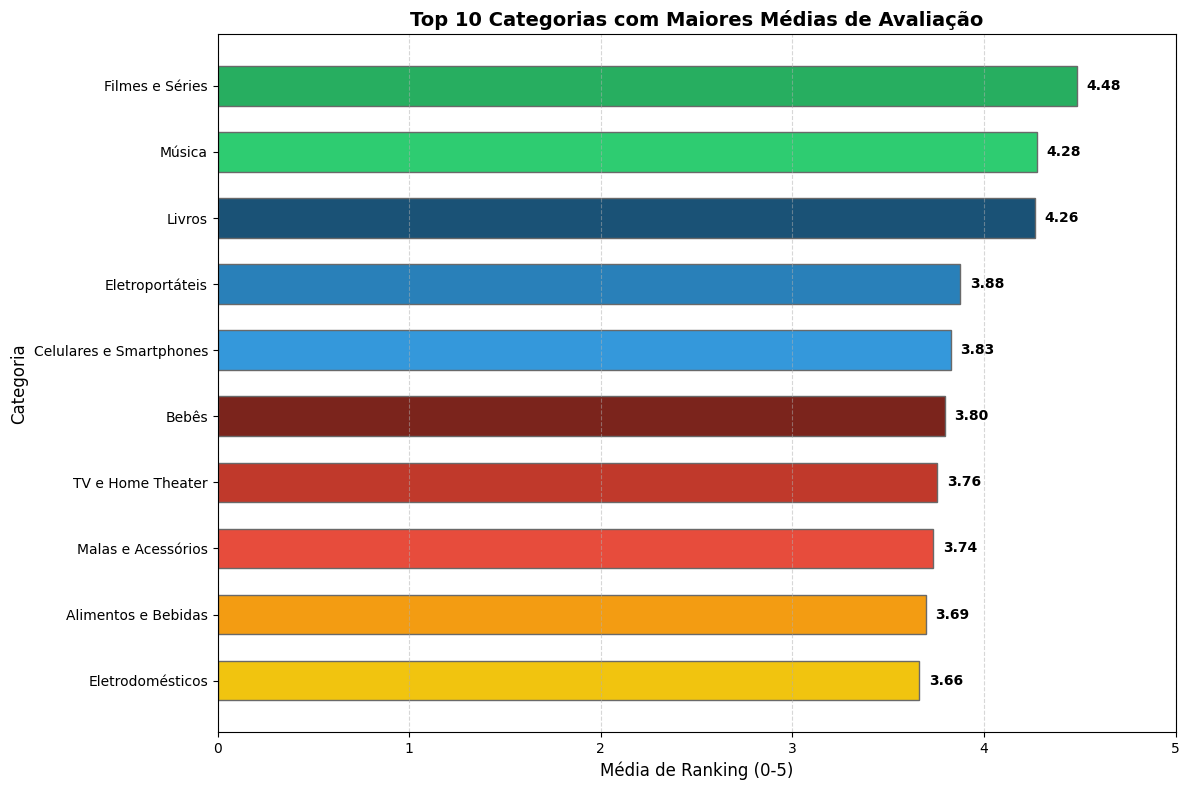

In [ ]:
# 2. Filtrar categorias com amostragem relevante (mínimo de 50 avaliações)
contagem_por_categoria = df['site_category_lv1'].value_counts()
categorias_validas = contagem_por_categoria[contagem_por_categoria >= 50].index
df_filtrado = df[df['site_category_lv1'].isin(categorias_validas)]

# 3. Calcular a média de avaliação por categoria e selecionar as 10 maiores
top_10_maiores_medias = (
    df_filtrado.groupby('site_category_lv1')['overall_rating']
    .mean()
    .sort_values(ascending=False)  # Ordena do maior para o menor para o topo começar com a maior média
    .head(10)
)

# Converter para DataFrame para facilitar a manipulação dos eixos
df_grafico = top_10_maiores_medias.reset_index()

# 4. Definir a paleta exata na ordem pedida:
# 1ª Verde Escuro, 2ª Verde Claro, 3 tons de Azul, 3 tons de Vermelho e os últimos em Amarelo
cores_especificas = [
    '#27ae60', '#2ecc71',              # 1ª Verde Escuro, 2ª Verde Claro
    '#1a5276', '#2980b9', '#3498db',  # 3 tons de Azul (Escuro, Médio, Claro)
    '#7b241c', '#c0392b', '#e74c3c',  # 3 tons de Vermelho (Escuro, Médio, Claro)
    '#f39c12', '#f1c40f'              # Últimos em tons de Amarelo (Escuro, Claro)
]

# 5. Criar a visualização do histograma horizontal
plt.figure(figsize=(12, 8))

# Plotando as barras horizontais
plt.barh(df_grafico['site_category_lv1'],
         df_grafico['overall_rating'],
         color=cores_especificas,
         edgecolor='dimgray',
         height=0.6)

# Configurações visuais do gráfico
plt.title('Top 10 Categorias com Maiores Médias de Avaliação', fontsize=14, fontweight='bold')
plt.xlabel('Média de Ranking (0-5)', fontsize=12)
plt.ylabel('Categoria', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Inverter o eixo Y para que a primeira linha (maior média) fique no topo do gráfico
plt.gca().invert_yaxis()

# Definir limite do eixo X (escala de notas de 0 a 5)
plt.xlim(0, 5)

# Adicionar os valores exatos na ponta de cada barra
for index, row in df_grafico.iterrows():
    plt.text(row['overall_rating'] + 0.05, index, f"{row['overall_rating']:.2f}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()

# Exibir o gráfico
plt.show()

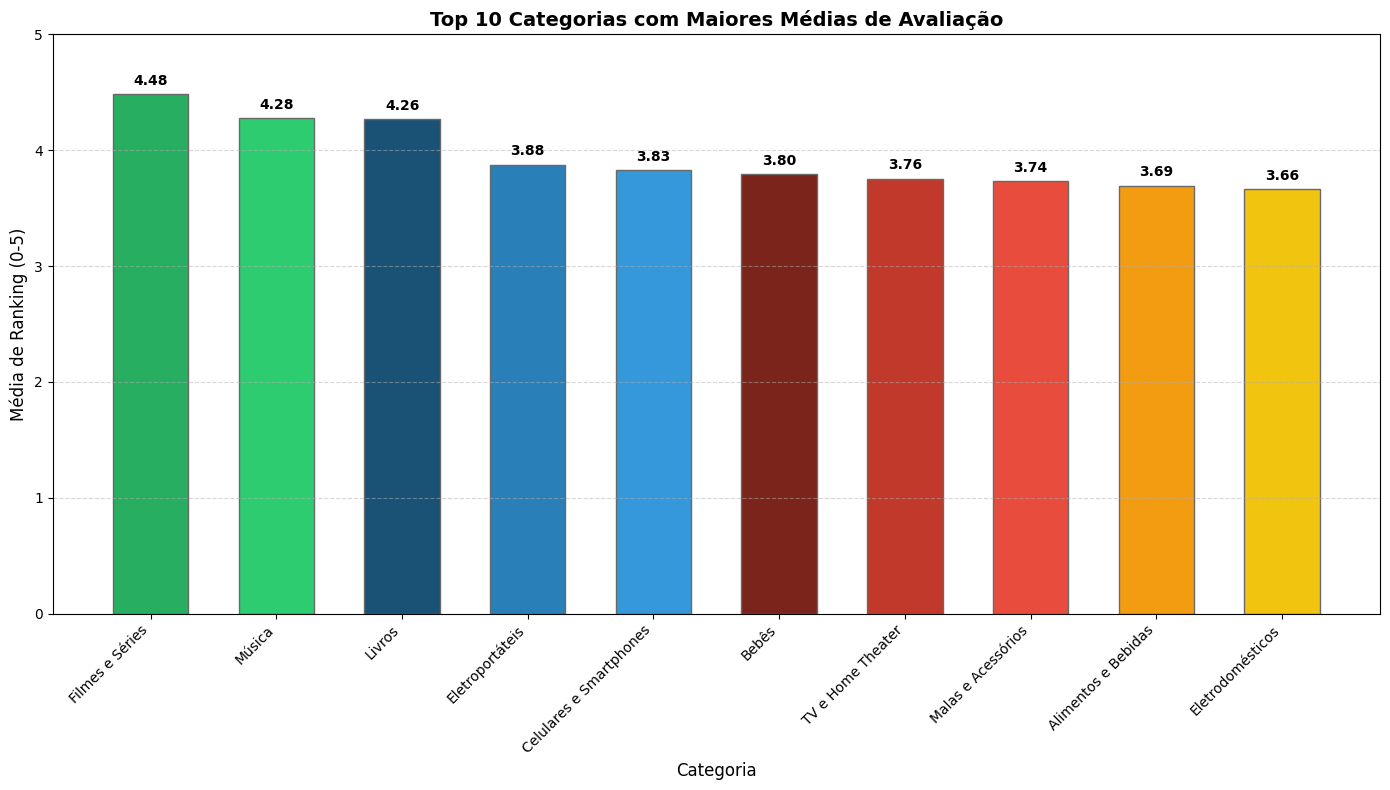

In [ ]:
# 2. Filtrar categorias com amostragem relevante (mínimo de 50 avaliações)
contagem_por_categoria = df['site_category_lv1'].value_counts()
categorias_validas = contagem_por_categoria[contagem_por_categoria >= 50].index
df_filtrado = df[df['site_category_lv1'].isin(categorias_validas)]

# 3. Calcular a média de avaliação por categoria e selecionar as 10 maiores
top_10_maiores_medias = (
    df_filtrado.groupby('site_category_lv1')['overall_rating']
    .mean()
    .sort_values(ascending=False)  # Ordena do maior para o menor (da esquerda para a direita)
    .head(10)
)

# Converter para DataFrame para facilitar o plot no eixo vertical
df_grafico = top_10_maiores_medias.reset_index()

# 4. Definir a paleta exata na ordem pedida (aplicada da esquerda para a direita):
# 1ª Verde Escuro, 2ª Verde Claro, 3 tons de Azul, 3 tons de Vermelho e últimas em Amarelo
cores_especificas = [
    '#27ae60', '#2ecc71',              # 1ª Verde Escuro, 2ª Verde Claro
    '#1a5276', '#2980b9', '#3498db',  # 3 tons de Azul
    '#7b241c', '#c0392b', '#e74c3c',  # 3 tons de Vermelho
    '#f39c12', '#f1c40f'              # Últimos em tons de Amarelo
]

# 5. Criar a visualização do histograma vertical (bar)
plt.figure(figsize=(14, 8))

# Plotando as barras verticais
plt.bar(df_grafico['site_category_lv1'],
        df_grafico['overall_rating'],
        color=cores_especificas,
        edgecolor='dimgray',
        width=0.6)

# Configurações visuais do gráfico
plt.title('Top 10 Categorias com Maiores Médias de Avaliação', fontsize=14, fontweight='bold')
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Média de Ranking (0-5)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Rotacionar os nomes das categorias no eixo X para leitura confortável
plt.xticks(rotation=45, ha='right')

# Definir limite do eixo Y (escala de notas de 0 a 5)
plt.ylim(0, 5)

# Adicionar os valores exatos no topo de cada barra
for index, row in df_grafico.iterrows():
    plt.text(index, row['overall_rating'] + 0.08, f"{row['overall_rating']:.2f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()

# Exibir o gráfico
plt.show()

Figura 5 - Top 10 categorias com menor média de avaliação.


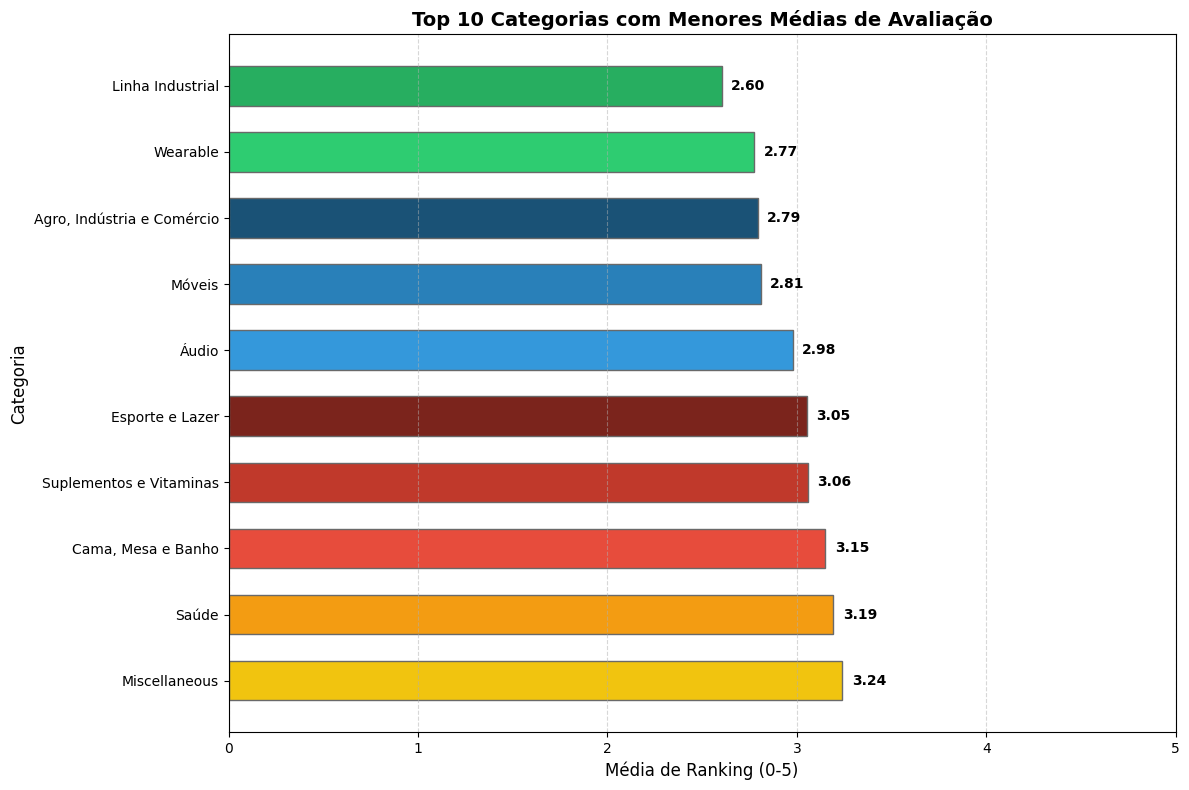

In [ ]:
# 2. Filtrar categorias com amostragem relevante (mínimo de 50 avaliações)
contagem_por_categoria = df['site_category_lv1'].value_counts()
categorias_validas = contagem_por_categoria[contagem_por_categoria >= 50].index
df_filtrado = df[df['site_category_lv1'].isin(categorias_validas)]

# 3. Calcular a média de avaliação por categoria e selecionar as 10 MENORES
# O .sort_values(ascending=True).head(10) garante que começamos pela pior média absoluta
top_10_piores_medias = (
    df_filtrado.groupby('site_category_lv1')['overall_rating']
    .mean()
    .sort_values(ascending=True)
    .head(10)
)

# Converter para DataFrame para facilitar o mapeamento de eixos
df_grafico = top_10_piores_medias.reset_index()

# 4. Definir a paleta na ordem pedida (de cima para baixo no gráfico):
# 1ª Verde Escuro, 2ª Verde Claro, 3 tons de Azul, 3 tons de Vermelho e as últimas em Amarelo
cores_especificas = [
    '#27ae60', '#2ecc71',              # 1ª Verde Escuro, 2ª Verde Claro
    '#1a5276', '#2980b9', '#3498db',  # 3 tons de Azul (Escuro, Médio, Claro)
    '#7b241c', '#c0392b', '#e74c3c',  # 3 tons de Vermelho (Escuro, Médio, Claro)
    '#f39c12', '#f1c40f'              # Últimas em tons de Amarelo (Escuro, Claro)
]

# 5. Criar a visualização do histograma horizontal
plt.figure(figsize=(12, 8))

# Plotando as barras horizontais
plt.barh(df_grafico['site_category_lv1'],
         df_grafico['overall_rating'],
         color=cores_especificas,
         edgecolor='dimgray',
         height=0.6)

# Configurações visuais do gráfico
plt.title('Top 10 Categorias com Menores Médias de Avaliação', fontsize=14, fontweight='bold')
plt.xlabel('Média de Ranking (0-5)', fontsize=12)
plt.ylabel('Categoria', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Forçar o eixo Y a começar de cima para baixo (a menor média absoluta fica no topo, em verde escuro)
plt.gca().invert_yaxis()

# Definir limite do eixo X (escala de notas de 0 a 5)
plt.xlim(0, 5)

# Adicionar os valores exatos na ponta de cada barra
for index, row in df_grafico.iterrows():
    plt.text(row['overall_rating'] + 0.05, index, f"{row['overall_rating']:.2f}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()

# Exibir o gráfico
plt.show()

Itens com muitas opiniões

In [ ]:
# 2. Agrupar apenas pelo Nome do produto para contar a quantidade de opiniões
listagem_opinioes = (
    df.groupby('product_name')
    .size()
    .reset_index(name='Quantidade de Opiniões')
    .sort_values(by='Quantidade de Opiniões', ascending=False)
)

# 3. Exibir o Top 50 itens com mais opiniões (apenas as duas colunas solicitadas)
print(listagem_opinioes.head(50).to_string(index=False))

# Criar a variável top_70000_opinioes a partir de listagem_opinioes
top_70000_opinioes = listagem_opinioes.head(70000)
top_70000_opinioes.to_csv('/content/drive/MyDrive/Seminario/top_70000_produtos_opinioes.csv', index=False, encoding='utf-8')

                                                                                                                                product_name  Quantidade de Opiniões
                        Smartphone Motorola Moto G 5S Dual Chip Android 7.1.1 Nougat Tela 5.2" Snapdragon 430 32GB 4G Câmera 16MP - Platinum                     449
                                            Smartphone Samsung Galaxy J7 Metal Dual Chip Android 6.0 Tela 5.5" 16GB 4G Câmera 13MP - Dourado                     403
                                                                                   Aspirador de Pó Philco Rapid 1000N Vermelho/Preto - 1000W                     400
                         Smartphone Motorola Moto G 5S Dual Chip Android 7.1.1 Nougat Tela 5.2" Snapdragon 430 32GB 4G Câmera 16MP - Dourado                     331
                                                Smartphone Samsung Galaxy J7 Prime Dual Chip Android Tela 5.5" 32GB 4G Câmera 13MP - Dourado                     300
Smartphone

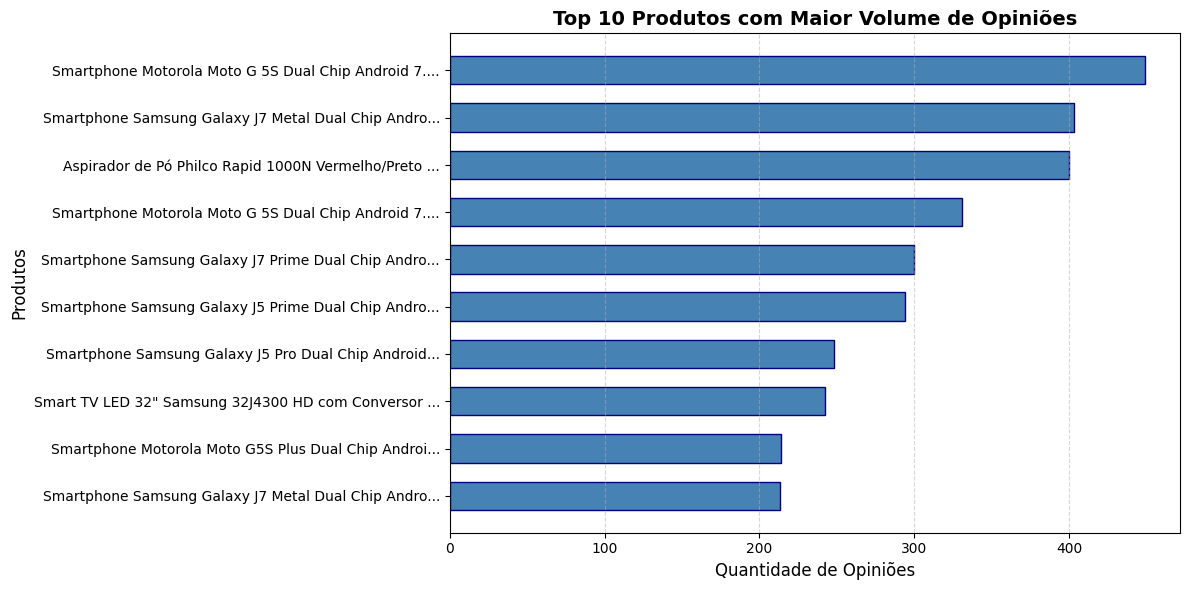

In [ ]:
#Histograma dos Top 10 Produtos com Maior Volume de Opiniões
# 2. Agrupar pelo nome do produto e contar a quantidade de opiniões
top_10_produtos = (
    df.groupby('product_name')
    .size()
    .reset_index(name='Quantidade de Opiniões')
    .sort_values(by='Quantidade de Opiniões', ascending=True) # Mantém o mais opinado no topo
    .tail(10)
)

# 3. Criar o gráfico de barras horizontal (Histograma)
plt.figure(figsize=(12, 6))
plt.barh(top_10_produtos['product_name'],
         top_10_produtos['Quantidade de Opiniões'],
         color='steelblue',
         edgecolor='navy',
         height=0.6)

# Configurações de títulos e eixos
plt.title('Top 10 Produtos com Maior Volume de Opiniões', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Opiniões', fontsize=12)
plt.ylabel('Produtos', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Encurtar nomes de produtos muito longos no eixo Y para melhor leitura
nomes_curtos = [nome[:50] + '...' if len(nome) > 50 else nome for nome in top_10_produtos['product_name']]
plt.yticks(range(10), nomes_curtos)

plt.tight_layout()

# Exibir o gráfico
plt.show()

#Considerando o overall-rating

/tmp/ipykernel_10966/222685596.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='overall_rating', palette='viridis')


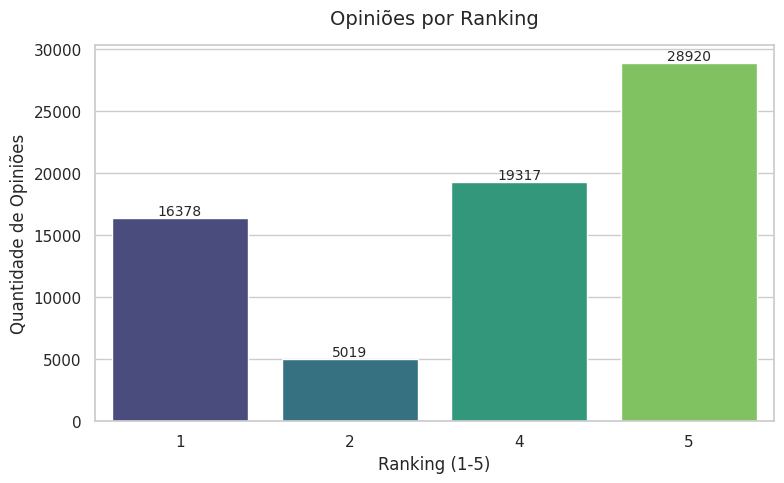

In [ ]:
# 2. Configurar o estilo visual do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# 3. Criar o gráfico de contagem (histograma para variáveis discretas)
ax = sns.countplot(data=df, x='overall_rating', palette='viridis')

# 4. Customizar títulos e rótulos
plt.title('Opiniões por Ranking', fontsize=14, pad=15)
plt.xlabel('Ranking (1-5)', fontsize=12)
plt.ylabel('Quantidade de Opiniões', fontsize=12)

# 5. Adicionar os valores exatos em cima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5),
                textcoords='offset points', fontsize=10)

# 6. Exibir o gráfico
plt.tight_layout()
plt.show()

/tmp/ipykernel_10966/1261638068.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Polo', order=ordem, palette=cores)


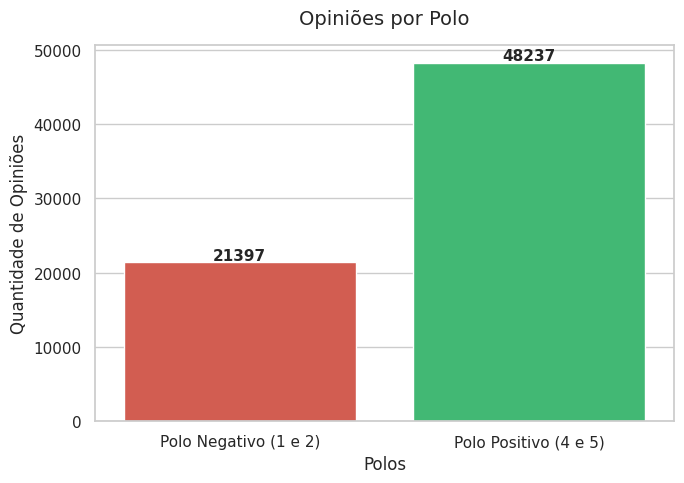

In [ ]:
#Visualização considerando os polos: 1 e 2 / 4 e 5

# 2. Criar uma função para agrupar as notas nos polos
def mapear_polo(rating):
    if rating in [1, 2]:
        return 'Polo Negativo (1 e 2)'
    elif rating in [4, 5]:
        return 'Polo Positivo (4 e 5)'
    return 'Outros'

# 3. Aplicar o agrupamento no DataFrame
df['Polo'] = df['overall_rating'].apply(mapear_polo)

# 4. Configurar o visual do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

# Definir a ordem das colunas e as cores (Vermelho para Negativo, Verde para Positivo)
ordem = ['Polo Negativo (1 e 2)', 'Polo Positivo (4 e 5)']
cores = ['#e74c3c', '#2ecc71']

# 5. Criar o gráfico de barras
ax = sns.countplot(data=df, x='Polo', order=ordem, palette=cores)

plt.title('Opiniões por Polo', fontsize=14, pad=15)
plt.xlabel('Polos', fontsize=12)
plt.ylabel('Quantidade de Opiniões', fontsize=12)

# 6. Adicionar os valores exatos em cima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5),
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Analisando o número de avaliações por item

In [3]:
# 2. Agrupa pelo nome do produto e conta a quantidade de avaliações
contagem_avaliacoes = df.groupby('product_name').size().reset_index(name='quantidade_avaliacoes')

# 3. Ordena os produtos do que tem mais avaliações para o que tem menos
contagem_avaliacoes = contagem_avaliacoes.sort_values(by='quantidade_avaliacoes', ascending=False)

# 4. Salva o resultado final em um novo arquivo CSV
contagem_avaliacoes.to_csv('/content/drive/MyDrive/Seminario/contagem_avaliacoes_produtos.csv', index=False, encoding='utf-8')

print("Processamento concluído com sucesso!")

Processamento concluído com sucesso!


/tmp/ipykernel_1838/3690284428.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


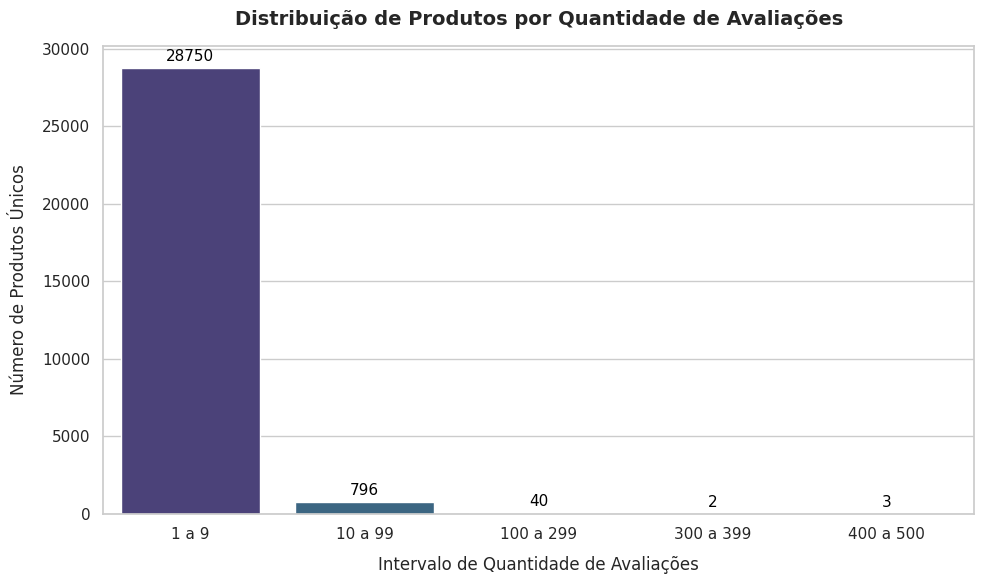

In [5]:
# 2. Contar a quantidade de avaliações por produto
contagem_avaliacoes = df.groupby('product_name').size().reset_index(name='quantidade')

# 3. Definir os limites dos intervalos (bins) e os rótulos de texto
# Nota: Os limites incluem o valor inferior e superior de cada faixa definida
limites = [0, 9, 99, 299, 399, 500]
rotulos = ['1 a 9', '10 a 99', '100 a 299', '300 a 399', '400 a 500']

# 4. Agrupar os produtos nos intervalos definidos
contagem_avaliacoes['faixa_avaliacoes'] = pd.cut(
    contagem_avaliacoes['quantidade'],
    bins=limites,
    labels=rotulos,
    include_lowest=True
)

# 5. Contar quantos produtos existem em cada faixa
dados_grafico = contagem_avaliacoes['faixa_avaliacoes'].value_counts().reindex(rotulos).reset_index()
dados_grafico.columns = ['Faixa de Avaliações', 'Quantidade de Produtos']

# 6. Configurar e gerar o gráfico (Histograma/Gráfico de Barras por Faixa)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Criando o gráfico de barras
ax = sns.barplot(
    x='Faixa de Avaliações',
    y='Quantidade de Produtos',
    data=dados_grafico,
    palette='viridis'
)

# Adicionar os números exatos no topo de cada barra para facilitar a leitura
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='baseline',
        fontsize=11, color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Títulos e legendas
plt.title('Distribuição de Produtos por Quantidade de Avaliações', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Intervalo de Quantidade de Avaliações', fontsize=12, labelpad=10)
plt.ylabel('Número de Produtos Únicos', fontsize=12, labelpad=10)

# Ajustar o layout e exibir
plt.tight_layout()
plt.show()

Avaliação de Desalinhamento de Sentimento

Caso 1a - Nota positiva (4 ou 5), mas não recomenda o produto* O consumidor atribuiu uma nota alta, porém afirmou que não recomendaria o produto.

Caso 1b - Nota negativa (1 ou 2), mas recomenda o produto O consumidor atribuiu uma nota baixa, porém afirmou que recomendaria o produto.

In [13]:
# --- CASO 1a: Nota positiva (4 ou 5), mas NÃO recomenda o produto ---
caso_1a = df2[
    (df2['overall_rating'].isin([4, 5])) &
    (df2['recommend_to_a_friend'].str.lower() == 'no')
]

print("=" * 70)
print("CASO 1a - Nota positiva (4 ou 5), mas NÃO recomenda o produto:")
print("=" * 70)
for idx, row in caso_1a[['overall_rating', 'recommend_to_a_friend', 'review_text']].head(4).iterrows():
    print(f"Nota: {row['overall_rating']} | Recomenda? {row['recommend_to_a_friend']}")
    print(f"Texto: {row['review_text']}")
    print("-" * 70)

print("\n" + "=" * 70)

# --- CASO 1b: Nota negativa (1 ou 2), mas RECOMENDA o produto ---
caso_1b = df2[
    (df2['overall_rating'].isin([1, 2])) &
    (df2['recommend_to_a_friend'].str.lower() == 'yes')
]

print("CASO 1b - Nota negativa (1 ou 2), mas RECOMENDA o produto:")
print("=" * 70)
for idx, row in caso_1b[['overall_rating', 'recommend_to_a_friend', 'review_text']].head(4).iterrows():
    print(f"Nota: {row['overall_rating']} | Recomenda? {row['recommend_to_a_friend']}")
    print(f"Texto: {row['review_text']}")
    print("-" * 70)

CASO 1a - Nota positiva (4 ou 5), mas NÃO recomenda o produto:
Nota: 4 | Recomenda? No
Texto: Plástico de boa qualidade, porém não tem muitas posições para colocá-lo em pé.  Acho que fica muito inclinado, praticamente entre 25 e 45 graus.  O ideal seria chega algo próximo dos 90º.
----------------------------------------------------------------------
Nota: 4 | Recomenda? No
Texto: queria saber se esse fone e USB se for USB compro agr
----------------------------------------------------------------------
Nota: 5 | Recomenda? No
Texto: Não recomendado. Embora o preço seja atraente não vale a pena, principalmente pela má qualidade dos garfos que entorta facilmente. Material frágil.  Pra ser da Tramontina esperava mais.
----------------------------------------------------------------------
Nota: 4 | Recomenda? No
Texto: Ainda não recebi o produto....gostaria de saber o que está acontecendo.....
----------------------------------------------------------------------

CASO 1b - Nota negativa 

Desalinhamento entre inferência do modelo e nota do consumidor

Caso 2a -Inferido como positivo, mas nota negativa (1 ou 2) O modelo classificou o texto como positivo, mas o consumidor atribuiu uma nota baixa.

Caso 2b - Inferido como negativo, mas nota positiva (4 ou 5) O modelo classificou o texto como negativo, mas o consumidor atribuiu uma nota alta.

In [14]:
# --- CASO 2a: Inferido como positivo (1), mas nota negativa (1 ou 2) ---
caso_2a = df2[
    (df2['inferencia_bertimbau'] == 1) &
    (df2['overall_rating'].isin([1, 2]))
]

print("=" * 75)
print("CASO 2a - Inferido como POSITIVO (1), mas nota NEGATIVA (1 ou 2):")
print("=" * 75)
for idx, row in caso_2a[['overall_rating', 'inferencia_bertimbau', 'probabilidade_bertimbau', 'review_text']].head(4).iterrows():
    print(f"Nota Original: {row['overall_rating']} | IA Predisse: POSITIVO ({row['probabilidade_bertimbau']:.2%})")
    print(f"Texto: {row['review_text']}")
    print("-" * 75)

print("\n" + "=" * 75)

# --- CASO 2b: Inferido como negativo (0), mas nota positiva (4 ou 5) ---
caso_2b = df2[
    (df2['inferencia_bertimbau'] == 0) &
    (df2['overall_rating'].isin([4, 5]))
]

print("CASO 2b - Inferido como NEGATIVO (0), mas nota POSITIVA (4 ou 5):")
print("=" * 75)
for idx, row in caso_2b[['overall_rating', 'inferencia_bertimbau', 'probabilidade_bertimbau', 'review_text']].head(4).iterrows():
    print(f"Nota Original: {row['overall_rating']} | IA Predisse: NEGATIVO ({row['probabilidade_bertimbau']:.2%})")
    print(f"Texto: {row['review_text']}")
    print("-" * 75)

CASO 2a - Inferido como POSITIVO (1), mas nota NEGATIVA (1 ou 2):
Nota Original: 2 | IA Predisse: POSITIVO (80.02%)
Texto: Produto muito bom, pena que não tem nem um mês de uso e está dando mal contato no carregador, tem vezes que é um sacrifício para carregar e a entrega deixou a desejar, demorou muito!
---------------------------------------------------------------------------
Nota Original: 2 | IA Predisse: POSITIVO (72.40%)
Texto: muito baixa pra ultilizar  é necessario  ficar sentado numa cadeira
---------------------------------------------------------------------------
Nota Original: 2 | IA Predisse: POSITIVO (86.97%)
Texto: Achei o design lindo, eu estava pensando em comprar, desisti por causa da garantia, 03 meses, sendo que a maioria dos eletrodomesticos e de um ano
---------------------------------------------------------------------------
Nota Original: 2 | IA Predisse: POSITIVO (77.71%)
Texto: Fiz a compra dia 12/04/2018 era pra ter chegado dia 30/04/2018 e chegou hoje 19/